In [1]:
import os
import pickle
import pandas as pd
from astroquery.ipac.ned import Ned
from astroquery.utils.tap.core import TapPlus
from concurrent.futures import ThreadPoolExecutor, as_completed

# 1. Cargar o inicializar el corte en redshift
try:
    with open('extra/redshift_init_ned.pickle', 'rb') as f:
        z_init = pickle.load(f)  # reanudar desde donde quedó
except FileNotFoundError:
    z_init = 0.0  # inicio en 0 si es la primera ejecución
# Justificación: así podemos reanudar sin volver a procesar objetos ya descargados.

batch_size = 50000   # número de objetos por consulta ADQL
all_entries = []     # lista para almacenar resultados

# 2. Bucle paginando por redshift
while True:
    # 2.1 Construir consulta ADQL usando columnas en minúsculas
    adql = (
        f"SELECT TOP {batch_size} objname, z "
        f"FROM objdir "
        f"WHERE z >= {z_init:.7f} AND z < 9.0 "
        f"ORDER BY z"
    )
    tap = TapPlus(url="https://ned.ipac.caltech.edu/tap")
    job = tap.launch_job(adql)  # envío síncrono
    table = job.get_results().to_pandas()
    if table.empty:
        break  # no hay más objetos
    # Justificación: 'objname' y 'z' funcionan, mientras que 'objName' falla :contentReference[oaicite:1]{index=1}.

    # 3. Para cada objeto, descargar espectros FITS con astroquery
    for name, z in zip(table['objname'], table['z']):
        try:
            spectra = Ned.get_spectra(name, show_progress=False)
        except Exception:
            continue  # ignora objetos sin espectro disponible

        for idx, hdulist in enumerate(spectra, start=1):
            # 4. Guardar FITS en disco
            safe_name = name.replace(' ', '_')
            filename = f"{safe_name}_z{z:.5f}_{idx}.fits"
            outdir = "spectrums_ned"
            os.makedirs(outdir, exist_ok=True)
            path = os.path.join(outdir, filename)
            hdulist.writeto(path, overwrite=True)
            all_entries.append({
                "objname": name,
                "redshift": float(z),
                "fits_path": path
            })
    # Justificación: Ned.get_spectra descarga directamente HDUList sin manejar URLs.

    # 5. Actualizar z_init para el siguiente lote
    last_z = float(table['z'].iloc[-1])
    z_init = last_z + 0.000002  # evitar bucles por z idénticos
    with open('extra/redshift_init_ned.pickle', 'wb') as f:
        pickle.dump(z_init, f)

# 6. Volcar resultados a DataFrame y pickle
df = pd.DataFrame(all_entries)
df.to_pickle('extra/all_results_ned.pickle')
print(f"Total de espectros descargados: {len(df)}")


HTTPError: Error 400: Incorrect ADQL query: 1 unresolved identifiers: objname [l.1 c.18 - l.1 c.25]!
  - Unknown column "objname" !

In [14]:
from astroquery.utils.tap.core import TapPlus

# Establecer conexión al servicio TAP de NED
ned_tap = TapPlus(url="https://ned.ipac.caltech.edu/tap")

# Consulta ADQL para obtener los nombres y descripciones de las tablas disponibles
adql_query = """
SELECT table_name, description 
FROM TAP_SCHEMA.tables
"""

# Ejecutar la consulta
job = ned_tap.launch_job(adql_query)
tables = job.get_results().to_pandas()

# Mostrar resultados
print(tables)


               table_name                                        description
0      TAP_SCHEMA.schemas     List of schemas published in this TAP service.
1       TAP_SCHEMA.tables      List of tables published in this TAP service.
2       TAP_SCHEMA.coosys  List of coordinate systems of coordinate colum...
3      TAP_SCHEMA.columns  List of columns of all tables listed in TAP_SC...
4         TAP_SCHEMA.keys  List all foreign keys but provides just the ta...
5  TAP_SCHEMA.key_columns  List all foreign keys but provides just the co...
6           NEDTAP.objdir                              NED object directory.


In [16]:
from astroquery.utils.tap.core import TapPlus

# Reutilizamos la conexión TAP creada antes
ned_tap = TapPlus(url="https://ned.ipac.caltech.edu/tap")

# Consulta ADQL para obtener las columnas de NEDTAP.objdir
adql_cols = """
SELECT column_name, description
  FROM TAP_SCHEMA.columns
 WHERE table_name = 'NEDTAP.objdir'
"""

# Ejecutar y volcar a DataFrame
job_cols = ned_tap.launch_job(adql_cols)
columns = job_cols.get_results().to_pandas()

# Mostrar las columnas disponibles
print(columns)


   column_name                                        description
0        objid          Internal identifier for the object in NED
1     prefname                              preferred object name
2      pretype                          NED preferred object type
3           ra  RA in decimal degrees of the object Equatorial...
4          dec  DEC in decimal degrees of the object Equatoria...
5       gallon        Galactic Longitude in degrees of the object
6       gallat         Galactic Latitude in degrees of the object
7      bhextin  Foreground Galactic Extinction based on Burste...
8      uncmaja  Uncertainty Ellipse, Semimajor Axis in arcseconds
9      uncmina  Uncertainty Ellipse, Semiminor Axis in arcseconds
10     uncposa  Uncertainty Ellipse, PA in degrees (East of No...
11     refcode             Reference Code for the object position
12       zflag                                      Redshift flag
13           z                                     Redshift in z.
14        

In [18]:
from astroquery.utils.tap.core import TapPlus

# Reutilizar la conexión TAP
ned_tap = TapPlus(url="https://ned.ipac.caltech.edu/tap")

# Parámetros de paginación
batch_size = 50000
# z_init ya lo cargaste del pickle en pasos anteriores

# Consulta ADQL con filtro n_spectra > 0
adql_query = f"""
SELECT TOP {batch_size}
    objid,
    prefname,
    ra,
    dec,
    z,
    n_spectra
FROM NEDTAP.objdir
WHERE
    z >= 3
    AND z < 3.2
    AND n_spectra > 0
ORDER BY z
"""

# Ejecutar el job
job = ned_tap.launch_job(adql_query)
table = job.get_results().to_pandas()

# Mostrar los primeros registros y el total
print(table.head(200))
print(f"Total en este lote: {len(table)}")

        objid                        prefname          ra        dec  \
0     2927212  WISEA J020732.20-341640.7        31.884187 -34.277982   
1     7563431  WISEA J155112.47+511856.7       237.801998  51.315756   
2    81633152  WISEA J105242.74+280501.6       163.178150  28.083708   
3     4250769  WISEA J230037.72-264435.8       345.157192 -26.743293   
4     7848689  WISEA J140218.26-014622.0       210.576340  -1.772789   
..        ...                             ...         ...        ...   
195   7734383  SDSS J094522.68+395414.6        146.344540  39.904060   
196   8114432  WISEA J110155.74+105302.2       165.482258  10.883950   
197  78474641  WISEA J115633.18+282123.1       179.138337  28.356182   
198   7850801  WISEA J112054.98+055205.7       170.229110   5.868044   
199  81945922  WISEA J105517.05+282418.5       163.821020  28.405197   

            z  n_spectra  
0    3.000000          1  
1    3.000124          1  
2    3.000125          1  
3    3.000237          1  


In [19]:
import os
import pickle
from astroquery.ipac.ned import Ned

# Parámetros del objeto detectado
obj_name = "WISEA J110155.74+105302.2"
obj_z    = 7.003068  # redshift obtenido

# 4.1 Descargar espectros FITS con astroquery
# Justificación: Ned.get_spectra devuelve una lista de HDUList, uno por cada espectro.
spectra = Ned.get_spectra(obj_name, show_progress=True)

# 4.2 Guardar cada HDUList en disco
output_dir = "spectrums_ned"
os.makedirs(output_dir, exist_ok=True)
for idx, hdulist in enumerate(spectra, start=1):
    # Nombrado seguro para el archivo
    safe_name = obj_name.replace(" ", "_")
    filename  = f"{safe_name}_z{obj_z:.5f}_{idx}.fits"
    path      = os.path.join(output_dir, filename)
    hdulist.writeto(path, overwrite=True)
    print(f"Guardado: {path}")
# Justificación: writeto(...) persiste localmente el FITS para su ingesta en BD.

# 4.3 Actualizar z_init para la siguiente iteración
new_z_init = obj_z + 0.000002  # pequeño salto para evitar bucles infinitos
with open('extra/redshift_init_ned.pickle', 'wb') as f:
    pickle.dump(new_z_init, f)
print(f"Punto de corte actualizado a z_init = {new_z_init:.7f}")
# Justificación: garantizamos que, al reanudar, no volvamos a procesar este mismo objeto.


Guardado: spectrums_ned\WISEA_J110155.74+105302.2_z7.00307_1.fits
Punto de corte actualizado a z_init = 7.0030700


In [ ]:
from astropy.io import fits  # 1. Leer archivos FITS
import numpy as np           # 2. Cálculos numéricos
import matplotlib.pyplot as plt  # 3. Plotting

# 4. Abrir el archivo FITS y extraer datos y cabecera
with fits.open('') as hdul:
    data   = hdul[0].data      # dato bidimensional: [flujo, cont., error, máscara, …]
    header = hdul[0].header    # metadatos con COEFF0/COEFF1, NAXIS1, etc.

# 5. Obtener número de píxeles espectrales
n_pix = header['NAXIS1']       # 3850 según cabecera

# 6. Construir eje de longitud de onda (vacío, log-linear SDSS)
coeff0 = header['COEFF0']      # 3.5799 → log10(wavelength) en píxel 0
coeff1 = header['COEFF1']      # 1e-4  → incremento en log10(wavelength)
pixels = np.arange(n_pix)      # vector de índices 0…n_pix-1
wave = 10**(coeff0 + coeff1 * pixels)  
#   → λ[i] = 10^(COEFF0 + COEFF1·i) en Ångströms

# 7. Seleccionar el array de flujo (extensión 0)
flux = data[0]                 # unidades 10⁻¹⁷ erg/s/cm²/Å

# 8. Graficar flujo vs longitud de onda
plt.figure()                   
plt.plot(wave, flux)           # trazar curva
plt.xlabel('Longitud de onda (Å)')  
plt.ylabel('Flujo (10⁻¹⁷ erg s⁻¹ cm⁻² Å⁻¹)')
plt.title(f"Espectro de {header.get('NAME','objeto')}, z={header.get('Z', '–')}")
plt.tight_layout()
plt.show()                     # mostrar gráfico

KeyError: "Keyword 'COEFF0' not found."

Usando dispositivo: cuda
Modelo Transformer configurado correctamente.
Redshift real:     4
Redshift predicho: 3.09940505027771


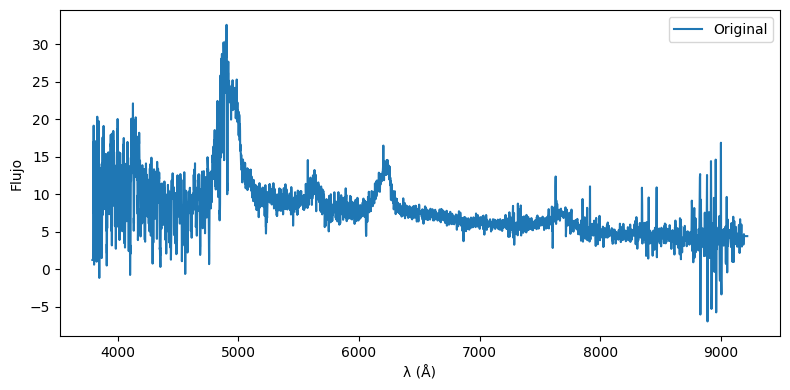

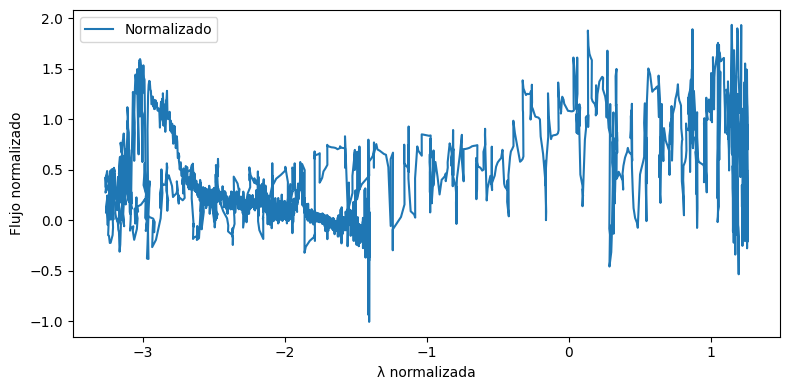

In [22]:
# =============
# CARGA DE LIBRERIAS

from astropy.io import fits
import gc
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import random
import torch
import torch.nn as nn
import torch.optim as optim
import random
import pickle
import numpy as np
import torch
from astropy.io import fits                          # manejo de FITS :contentReference[oaicite:2]{index=2}
import matplotlib.pyplot as plt
from astroquery.ipac.ned import Ned


# =============
# DEFINICIÓN Y CONFIGURACIÓN DEL MODELO

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class Transformer(nn.Module):
    def __init__(self, num_points, d_model=128, nhead=8, num_layers=4, dim_feedforward=256):
        super(Transformer, self).__init__()
        self.embedding = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=d_model, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(d_model),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=d_model, out_channels=d_model, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(d_model),
            nn.MaxPool1d(kernel_size=2)
        )
        reduced_len = num_points // 16
        self.positional_encoding = PositionalEncoding(d_model, dropout=0.1, max_len=reduced_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0.1, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.fc_layers = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = x.transpose(1, 2)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)
        x = x.transpose(1, 2)
        x = self.pooling(x).squeeze(-1)
        out = self.fc_layers(x)
        return out

# Instanciar el modelo y moverlo a GPU si está disponible
num_points = 5000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelTransformer = Transformer(num_points).to(device)

criterion = nn.L1Loss()
optimizer = optim.Adam(modelTransformer.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

print("Modelo Transformer configurado correctamente.")



test_redshift=4
# 4) Expandir/pad a num_points y escalado  
def expand_points(wl, fl, target_count):
    wl, fl = list(wl), list(fl)
    diffs = [abs(fl[i+1]-fl[i]) for i in range(len(fl)-1)]
    for idx in sorted(range(len(diffs)), key=lambda i: diffs[i], reverse=True):
        if len(wl)>=target_count: break
        wl.insert(idx+1, (wl[idx]+wl[idx+1])/2)
        fl.insert(idx+1, (fl[idx]+fl[idx+1])/2)
    return np.array(wl), np.array(fl)

num_points = 5000
wavelength, flux = expand_points(wave, flux, num_points)
wavelength, flux = expand_points(wavelength, flux, num_points)
wavelength, flux = expand_points(wavelength, flux, num_points)

with open('extra/scaler_fitted.pkl','rb') as f:
    scalers = pickle.load(f)
flux_scaler = scalers["flux_scaler"]                  # cargado previamente :contentReference[oaicite:10]{index=10}
wave_scaler = scalers["wavelength_scaler"]

# Normalización y tensor de entrada
f_in = flux.reshape(1,-1)
w_in = wavelength.reshape(1,-1)
f_s = flux_scaler.transform(f_in)
w_s = wave_scaler.transform(w_in)
inp = np.stack([f_s[0], w_s[0]], axis=0).reshape(1,2,num_points)
input_tensor = torch.from_numpy(inp).to(device)
input_tensor = input_tensor.float()

# 5) Carga modelo y predicción
checkpoint = torch.load('storage/modelTRA_1M.pth', map_location=device)
modelTransformer.load_state_dict(checkpoint['model_state_dict'])
modelTransformer.eval()
with torch.no_grad():
    pred_z = modelTransformer(input_tensor).item()

print("Redshift real:    ", test_redshift)
print("Redshift predicho:", pred_z)

# 6) Gráficos
plt.figure(figsize=(8,4))
plt.plot(wavelength, flux, label='Original') 
plt.xlabel('λ (Å)'); plt.ylabel('Flujo'); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
plt.plot(w_s.flatten(), f_s.flatten(), label='Normalizado')
plt.xlabel('λ normalizada'); plt.ylabel('Flujo normalizado'); plt.legend(); plt.tight_layout(); plt.show()